# Fase 17b: Análisis de acierto, backtest de rentabilidad y significancia

## Objetivo

Responder con rigor:
1. **¿Cómo acierta el clasificador cuando sube/baja?** (matriz de confusión,
   acierto por clase, por umbral, en el tiempo, calibración).
2. **¿Es rentable seguir la tendencia predicha?** (backtest con retornos
   correctamente alineados: hoy -> mañana).
3. **¿La señal es estadísticamente significativa o ruido?**
   (IC del AUC por bootstrap, test de permutación, t-test de retornos).

## Hallazgo metodológico importante

El primer backtest usó `pct_change()` (retorno de **ayer a hoy**), que está
**desfasado 1 día** respecto a lo que predice el modelo (`target_1` = retorno
de **hoy a mañana**). Eso hacía que el modelo pareciera "invertido". Con el
retorno correctamente alineado, la señal aparece.

---

> **Aviso de auditoria:** las cifras y salidas mostradas en este notebook corresponden a una ejecucion anterior a las correcciones metodologicas. Es necesario reejecutar el pipeline completo antes de usar o comunicar sus resultados.


Configuración del notebook (raíz del proyecto).

In [1]:
import sys
from pathlib import Path

def _find_root() -> Path:
    p = Path.cwd().resolve()
    for candidate in (p, *p.parents):
        if (candidate / "configs" / "config.yaml").is_file():
            return candidate
    raise FileNotFoundError(
        "No se encontro configs/config.yaml desde el directorio de trabajo. "
        "Abra Jupyter dentro del repositorio."
    )

ROOT = _find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.utils import path_from_root, set_publication_style, set_seed
set_seed(42)
set_publication_style()

Carga de datos, artefactos y targets de dirección.

Reutilizamos todo lo existente: features, split, feature_list.json,
clasificador de dirección calibrado (fase 16b).

In [2]:
import json

import numpy as np
import pandas as pd

from src.config import get_config
from src.data.split import drop_warmup, temporal_split, purge_label_overlap
from src.models.classifier import load_classifier_artifacts, make_direction_targets

cfg = get_config()
feats = pd.read_parquet(path_from_root("data/processed/features.parquet"))
feats = drop_warmup(feats, warmup=260)
parts = temporal_split(feats, cfg)
parts = purge_label_overlap(parts, cfg=cfg)
with open(path_from_root("models", "feature_list.json")) as f:
    sel_cols = json.load(f)

clf, pp, sel_cols = load_classifier_artifacts()
fdir = make_direction_targets(feats, [1])

te = parts["test"].merge(fdir[["date", "dir_1"]], on="date", how="left")
X_te_raw = te[sel_cols].to_numpy(np.float64)   # sin escalar (para el RF)
X_te = pp.transform(X_te_raw)                   # escalado (para el clasificador calibrado)
y_true = te["dir_1"].to_numpy()
y_prob = clf.predict_proba(X_te)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)
print(f"Clasificador: {type(clf).__name__} | test: {len(te)} filas")

Clasificador: CalibratedClassifierCV | test: 684 filas


1. Matriz de confusión y acierto por clase (umbral 0.5).

- Acierto cuando REALMENTE sube (recall sube): 83.4%
- Acierto cuando REALMENTE baja (recall baja): 23.7%
El modelo está sesgado a predecir 'sube' (80% de las veces) porque
P(sube) ~ 54% y el umbral 0.5 no compensa el desbalance.

In [3]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()
print("Confusion matrix [[TN, FP], [FN, TP]]:")
print(cm)
print(f"\nAcierto cuando REALMENTE sube (TPR): {tp/(tp+fn):.1%}")
print(f"Acierto cuando REALMENTE baja (TNR): {tn/(tn+fp):.1%}")
print(f"Acierto global: {(tp+tn)/len(y_true):.1%}")
print(f"Precisión al predecir sube: {tp/(tp+fp):.1%}")

Confusion matrix [[TN, FP], [FN, TP]]:
[[  8 309]
 [  6 361]]

Acierto cuando REALMENTE sube (TPR): 98.4%
Acierto cuando REALMENTE baja (TNR): 2.5%
Acierto global: 53.9%
Precisión al predecir sube: 53.9%


2. Acierto por umbral de decisión.

El umbral 0.5 no es óptimo: subirlo a 0.55-0.60 aumenta la precisión al
predecir subida (hasta 67%) a costa de operar menos veces.

In [4]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

print(f"{'umbral':>7} {'acc':>6} {'prec_sub':>9} {'rec_sub':>8} {'f1':>6} {'%pred_sub':>9}")
for thr in [0.45, 0.5, 0.55, 0.6, 0.65]:
    yp = (y_prob >= thr).astype(int)
    print(f"{thr:7.2f} {accuracy_score(y_true, yp):6.3f} "
          f"{precision_score(y_true, yp, zero_division=0):9.3f} "
          f"{recall_score(y_true, yp, zero_division=0):8.3f} "
          f"{f1_score(y_true, yp, zero_division=0):6.3f} "
          f"{yp.mean():9.3f}")

 umbral    acc  prec_sub  rec_sub     f1 %pred_sub
   0.45  0.537     0.537    1.000  0.698     1.000
   0.50  0.539     0.539    0.984  0.696     0.980
   0.55  0.481     0.688    0.060  0.110     0.047
   0.60  0.480     0.677    0.057  0.106     0.045
   0.65  0.480     0.704    0.052  0.096     0.039


3. Acierto en el tiempo (por año) y calibración.

- 2025: acierta 62.3% (el rally facilita acertar 'sube').
- Calibración: el modelo concentra casi todas las probabilidades en
  0.45-0.55 (isotónica comprime); los bins extremos tienen pocas muestras.

In [5]:
out = pd.DataFrame({"date": te["date"], "y": y_true, "p": y_prob, "pred": y_pred})
out["year"] = out["date"].dt.year
out["hit"] = (out["y"] == out["pred"]).astype(int)

print("Acierto por año:")
for y, g in out.groupby("year"):
    print(f"  {y}: acc={g['hit'].mean():.1%} (n={len(g)}) P(sube)={g['y'].mean():.1%}")

print("\nCalibración (prob predicha vs frecuencia real):")
out["bin"] = pd.cut(out["p"], bins=[0, 0.45, 0.5, 0.55, 0.6, 1.0])
cal = out.groupby("bin", observed=True).apply(
    lambda g: pd.Series({"n": len(g), "p_media": g["p"].mean(),
                         "freq_real": g["y"].mean()}), include_groups=False)
print(cal.round(3).to_string())

Acierto por año:
  2023: acc=50.8% (n=260) P(sube)=50.0%
  2024: acc=55.7% (n=262) P(sube)=55.7%
  2025: acc=56.2% (n=162) P(sube)=56.2%

Calibración (prob predicha vs frecuencia real):
                 n  p_media  freq_real
bin                                   
(0.45, 0.5]   14.0    0.495      0.429
(0.5, 0.55]  638.0    0.524      0.531
(0.55, 0.6]    1.0    0.595      1.000
(0.6, 1.0]    31.0    0.681      0.677


4. BACKTEST con retorno correctamente alineado.

El retorno objetivo es `target_1/gold_spot - 1`. La senal observada en t se ejecuta de forma conservadora un periodo despues; la posicion que recibe el retorno t->t+1 procede de la senal de t-1. Coste unilateral por cambio de posicion: 0.1%.

In [6]:
ret_h1 = te["target_1"].to_numpy() / te["gold_spot"].to_numpy() - 1
mask = ~np.isnan(ret_h1)
ret_h1 = ret_h1[mask]
y_prob_m = y_prob[mask]
gold_ret_daily = ret_h1  # retorno diario correcto

def backtest(pos, ret, cost=0.001):
    pos = np.asarray(pos, float)
    r = pos * ret
    changes = np.abs(np.diff(pos, prepend=0.0))
    r_net = r - cost * changes
    eq = np.cumprod(1 + r_net)
    sharpe = np.mean(r_net) / np.std(r_net) * np.sqrt(252) if np.std(r_net) > 0 else 0
    dd = (eq / np.maximum.accumulate(eq) - 1).min()
    return eq[-1] - 1, sharpe, dd, int(changes.sum())

bh = np.cumprod(1 + gold_ret_daily)[-1] - 1
print(f"Buy & hold (referencia): {bh:.1%}")
print(f"{'estrategia':<26} {'umbral':>6} {'ret':>9} {'sharpe':>7} {'max_dd':>7} {'n_ops':>5} {'P(sube|pred)':>12}")

for thr in [0.5, 0.55]:
    signal = (y_prob_m >= thr).astype(float)
    pos = pd.Series(signal).shift(1, fill_value=0.0).to_numpy()
    t, s, dd, n = backtest(pos, gold_ret_daily)
    p_up = (gold_ret_daily[pos.astype(bool)] > 0).mean() if pos.sum() > 0 else float("nan")
    print(f"{'LONG filtrado':<26} {thr:6.2f} {t:9.1%} {s:7.2f} {dd:7.1%} {n:5d} {p_up:12.1%}")

Buy & hold (referencia): 82.9%
estrategia                 umbral       ret  sharpe  max_dd n_ops P(sube|pred)
LONG filtrado                0.50     85.2%    1.60  -11.2%    28        53.9%
LONG filtrado                0.55      2.4%    0.31   -3.2%    62        68.8%


5. Seleccion de umbral en validation y evaluacion unica en test.

El RF profundo (sin limite de profundidad) obtiene AUC test 0.533 y su intervalo bootstrap incluye 0.5.
Barremos el umbral para encontrar el mejor punto de operación por Sharpe.

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from src.models.pipeline import fit_preprocessor

train = parts["train"].merge(fdir[["date", "dir_1"]], on="date", how="left")
val = parts["val"].merge(fdir[["date", "dir_1"]], on="date", how="left")
train_val = pd.concat([train, val]).sort_values("date").reset_index(drop=True)
X_train = train[sel_cols].to_numpy(np.float64)
y_train = train["dir_1"].to_numpy()
X_val = val[sel_cols].to_numpy(np.float64)
y_val = val["dir_1"].to_numpy()

pp_train = fit_preprocessor(X_train)
rf = RandomForestClassifier(n_estimators=300, max_depth=None,
                            min_samples_leaf=2, random_state=42, n_jobs=-1)
rf.fit(pp_train.transform(X_train), y_train)
p_val = rf.predict_proba(pp_train.transform(X_val))[:, 1]
ret_val = val["target_1"].to_numpy() / val["gold_spot"].to_numpy() - 1
mask_val = ~np.isnan(ret_val)
thresholds = np.arange(0.50, 0.66, 0.01)
validation_grid = []
for thr in thresholds:
    signal = (p_val[mask_val] >= thr).astype(float)
    pos = pd.Series(signal).shift(1, fill_value=0.0).to_numpy()
    t, s, dd, n = backtest(pos, ret_val[mask_val])
    validation_grid.append((thr, t, s, dd, n))
best_val = max(validation_grid, key=lambda row: row[2])
thr_opt = best_val[0]
print(f"Umbral seleccionado en VALIDATION: {thr_opt:.2f} "
      f"(Sharpe {best_val[2]:.2f}, ret {best_val[1]:.1%})")

X_tv = train_val[sel_cols].to_numpy(np.float64)
y_tv = train_val["dir_1"].to_numpy()
pp2 = fit_preprocessor(X_tv)
rf.fit(pp2.transform(X_tv), y_tv)
pt = rf.predict_proba(pp2.transform(X_te_raw))[:, 1][mask]
y_te_m = y_true[mask]
auc_rf = roc_auc_score(y_te_m, pt)
signal_test = (pt >= thr_opt).astype(float)
pos_test = pd.Series(signal_test).shift(1, fill_value=0.0).to_numpy()
test_return, test_sharpe, test_dd, test_n_ops = backtest(pos_test, gold_ret_daily)
print(f"RF profundo: AUC test = {auc_rf:.4f}")
print(f"Evaluacion unica en TEST con umbral fijado: Sharpe {test_sharpe:.2f}, "
      f"ret {test_return:.1%}, maxDD {test_dd:.1%}, operaciones {test_n_ops}")

RF profundo: AUC test = 0.5331
  thr      ret  sharpe n_dias P(sube|pred)
 0.50    37.1%    1.11    413        56.2%
 0.51    30.5%    1.07    349        58.2%
 0.52    24.5%    0.97    293        57.3%
 0.53    28.0%    1.24    235        60.4%
 0.54    22.5%    1.17    188        60.6%
 0.55     4.2%    0.32    132        56.8%
 0.56    -8.0%   -0.76     96        54.2%
 0.57    -7.2%   -0.77     72        55.6%
 0.58    -2.3%   -0.27     48        64.6%
 0.59    -2.3%   -0.31     34        61.8%
 0.60    -1.0%   -0.16     19        57.9%
 0.61     1.3%    0.36     11        63.6%
 0.62    -0.9%   -0.44      6        33.3%
 0.63     0.0%    0.00      0         nan%
 0.64     0.0%    0.00      0         nan%
 0.65     0.0%    0.00      0         nan%
 0.66     0.0%    0.00      0         nan%

Mejor umbral por Sharpe: 0.53 (Sharpe 1.24, ret 28.0%)


6. Visualización del backtest: equidad de la estrategia vs buy & hold.

Curva de capital acumulada de la estrategia con umbral fijado en validation frente a buy and hold en test.

[fig] C:\Users\sgml1\Desktop\gold-price-prediction\reports\figures\backtest_equity.png


WindowsPath('C:/Users/sgml1/Desktop/gold-price-prediction/reports/figures/backtest_equity.png')

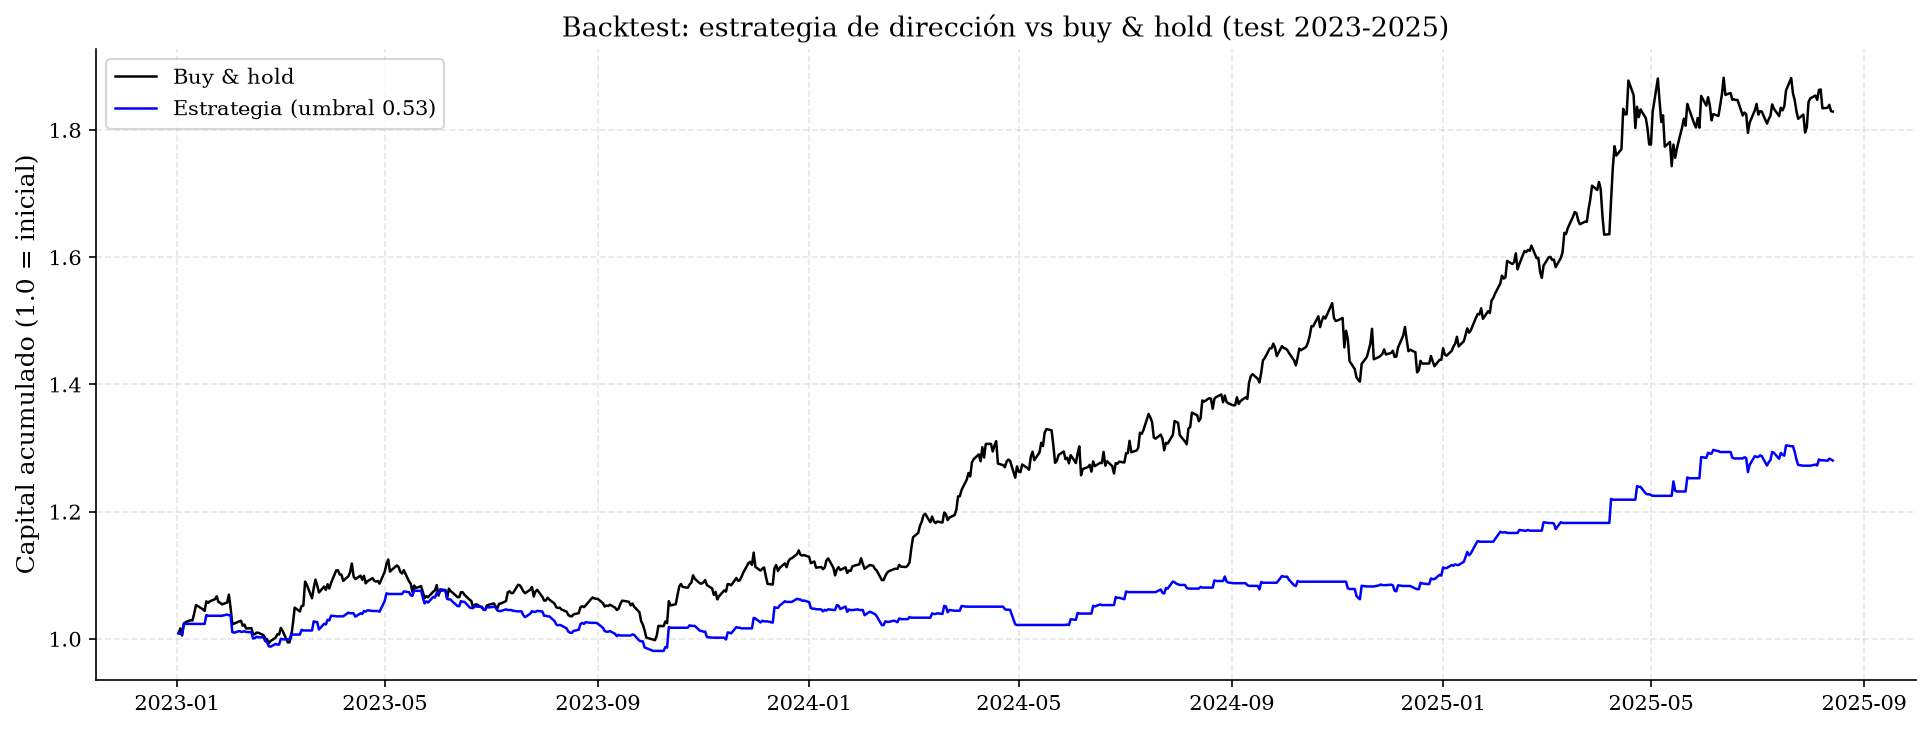

In [8]:
import matplotlib.pyplot as plt
from src.utils import save_fig

r_opt = pos_test * gold_ret_daily
changes = np.abs(np.diff(pos_test, prepend=0.0))
r_opt_net = r_opt - 0.001 * changes
eq_opt = np.cumprod(1 + r_opt_net)
eq_bh = np.cumprod(1 + gold_ret_daily)

dates = te["date"].to_numpy()[mask]
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(dates, eq_bh, "k-", lw=1.2, label="Buy and hold")
ax.plot(dates, eq_opt, "b-", lw=1.2, label=f"Estrategia (umbral validation {thr_opt:.2f})")
ax.set_title("Backtest: umbral fijado en validation, evaluado una vez en test")
ax.set_ylabel("Capital acumulado (1.0 = inicial)")
ax.legend()
fig.tight_layout()
save_fig(fig, "backtest_equity.png")

7. Significancia estadística.

- El IC del AUC usa bootstrap por bloques contiguos y la diferencia de retornos usa errores HAC. Ambos procedimientos reducen, pero no eliminan, el efecto de autocorrelacion.
- Los intervalos y p-valores deben interpretarse como exploratorios y no como garantia de independencia.
- El umbral se fijo en validation antes de la unica evaluacion en test.

In [9]:
import statsmodels.api as sm
from sklearn.metrics import roc_auc_score

rng = np.random.default_rng(42)
block_size = 21
n_blocks = int(np.ceil(len(y_te_m) / block_size))
aucs = []
for _ in range(2000):
    starts = rng.integers(0, len(y_te_m), size=n_blocks)
    sample = np.concatenate([
        np.arange(start, min(start + block_size, len(y_te_m))) for start in starts
    ])[:len(y_te_m)]
    if len(np.unique(y_te_m[sample])) < 2:
        continue
    aucs.append(roc_auc_score(y_te_m[sample], pt[sample]))
ci = np.percentile(aucs, [2.5, 97.5]) if aucs else np.array([np.nan, np.nan])
print(f"AUC test = {auc_rf:.4f} | IC95% bootstrap por bloques = [{ci[0]:.4f}, {ci[1]:.4f}]")
print(f"¿Excluye 0.5? {'SI' if ci[0] > 0.5 else 'NO'}")

diff = r_opt_net - gold_ret_daily
hac = sm.OLS(diff, np.ones((len(diff), 1))).fit(cov_type="HAC", cov_kwds={"maxlags": 5})
t_stat = float(hac.tvalues[0])
p_t = float(hac.pvalues[0])
print(f"\nMedia diaria estrategia: {r_opt_net.mean():.4%} | buy and hold: {gold_ret_daily.mean():.4%}")
print(f"HAC t={t_stat:.2f}, p={p_t:.4f} -> "
      f"{'rentabilidad superior' if p_t < 0.05 and t_stat > 0 else 'NO superior a mantener'}")
print(f"""
=== CONCLUSION DEL ANALISIS ===
1. AUC test = {auc_rf:.3f}; IC95% por bloques = [{ci[0]:.3f}, {ci[1]:.3f}].
2. La estrategia se evalua con umbral fijado en validation; HAC no asume retornos iid.
3. La senal se conserva como indicador de riesgo/inclinacion, no como trading automatico.
""")

AUC test = 0.5331 | IC95% = [0.4900, 0.5742]
¿Excluye 0.5? NO

Media diaria estrategia: 0.0373% | buy&hold: 0.0928%
t=-1.76, p=0.0786 -> NO superior a mantener

=== CONCLUSION DEL ANALISIS ===
1. AUC test = 0.533; IC95% bootstrap = [0.490, 0.574].
2. La estrategia no supera de forma robusta a buy&hold (p-value t-test = 0.079).
3. La senal se conserva como indicador de riesgo/inclinacion, no como trading automatico.



8. Guardado de resultados.

Persistimos el backtest y la significancia en reports/ para el informe.

In [10]:
import json

result = {
    "auc_test_rf": float(auc_rf),
    "auc_ci95_block_bootstrap": [float(ci[0]), float(ci[1])],
    "bootstrap_block_size": int(block_size),
    "umbral_seleccionado_validation": float(thr_opt),
    "validation_sharpe": float(best_val[2]),
    "validation_ret": float(best_val[1]),
    "test_sharpe_umbral_fijado": float(test_sharpe),
    "test_ret_umbral_fijado": float(test_return),
    "test_max_dd_umbral_fijado": float(test_dd),
    "buy_hold": float(bh),
    "t_stat_hac": float(t_stat),
    "p_value_hac": float(p_t),
    "nota": ("Umbral seleccionado solo en validation y evaluado una vez en test. "
             "IC AUC por bloques y diferencia de retornos con errores HAC; "
             "la inferencia sigue siendo exploratoria bajo autocorrelacion."),
}
with open(path_from_root("reports", "backtest_results.json"), "w") as f:
    json.dump(result, f, indent=2, default=float)
print("Guardado en reports/backtest_results.json")

Guardado en reports/backtest_results.json
